In [2]:
%cd /content/drive/MyDrive/Generation_of_Data_using_GAN

/content/drive/MyDrive/Generation_of_Data_using_GAN


Will generate 128px square images.
Looking for file: /content/drive/MyDrive/Generation_of_Data_using_GAN/data/training_data_128_128.npy
Loading training images...


100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


Saving training image binary...
Image preprocess time: 0:00:00.65
Epoch 1, gen loss=0.9739106893539429,disc loss=1.8805605173110962, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Epoch 2, gen loss=2.754566192626953,disc loss=1.2728091478347778, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Epoch 3, gen loss=2.8380446434020996,disc loss=0.3006173372268677, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Epoch 4, gen loss=2.461832284927368,disc loss=0.4835013151168823, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Epoch 5, gen loss=1.8345210552215576,disc loss=0.30137917399406433, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Epoch 6, gen loss=2.671452522277832,disc loss=0.2319221794605255, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Epoch 7, gen loss=2.9675512313842773,disc loss=0.12333794683218002, {hms_string(epoch_elapsed)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Epoch 

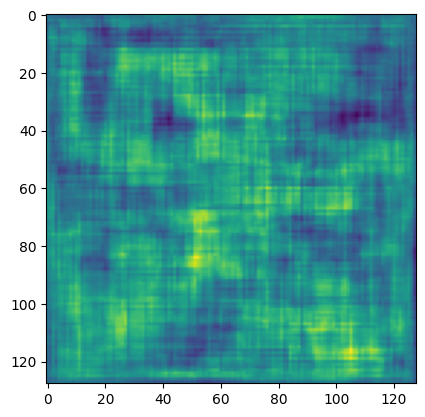

In [4]:
# Name: Syed


import tensorflow as tf
from tensorflow.keras.layers import Input, Reshape, Dropout, Dense
from tensorflow.keras.layers import Flatten, BatchNormalization
from tensorflow.keras.layers import Activation, ZeroPadding2D
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import Adam
import numpy as np
from PIL import Image
from tqdm import tqdm
import os
import time
import matplotlib.pyplot as plt

GENERATE_RES = 4 # Generation resolution factor
# (1=32, 2=64, 3=96, 4=128, etc.)
GENERATE_SQUARE = 32 * GENERATE_RES # rows/cols (should be square)
IMAGE_CHANNELS = 3

# Preview image
PREVIEW_ROWS = 1
PREVIEW_COLS = 1
PREVIEW_MARGIN = 16

# Size vector to generate images from
SEED_SIZE = 100

# Configuration
DATA_PATH = '/content/drive/MyDrive/Generation_of_Data_using_GAN/data'
EPOCHS = 1000
BATCH_SIZE = 32
BUFFER_SIZE = 60000

# Define image paths
path1 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/1.png'
path2 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/2.png'
path3 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/3.png'
path4 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/4.png'

print(f"Will generate {GENERATE_SQUARE}px square images.")

def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return "{}:{:>02}:{:>05.2f}".format(h, m, s)

training_binary_path = os.path.join(DATA_PATH,
        f'training_data_{GENERATE_SQUARE}_{GENERATE_SQUARE}.npy')

print(f"Looking for file: {training_binary_path}")

training_data = []

if not os.path.isfile(training_binary_path):
  start = time.time()
  print("Loading training images...")

  faces_path = os.path.join(DATA_PATH)
  for filename in tqdm(os.listdir(faces_path)):
      path = os.path.join(faces_path,filename)
      image = Image.open(path).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
      training_data.append(np.asarray(image))
  training_data = np.reshape(training_data,(-1,GENERATE_SQUARE,GENERATE_SQUARE,IMAGE_CHANNELS))
  training_data = training_data.astype(np.float32)
  training_data = training_data / 127.5 - 1.


  print("Saving training image binary...")
  np.save(training_binary_path,training_data)
  elapsed = time.time()-start
  print (f'Image preprocess time: {hms_string(elapsed)}')
else:
  print("Loading previous training pickle...")
  training_data = np.load(training_binary_path)

#shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(training_data) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

def build_generator(seed_size, channels):
    model = Sequential()

    model.add(Dense(4*4*256,activation="relu",input_dim=seed_size))
    model.add(Reshape((4,4,256)))

    model.add(UpSampling2D())
    model.add(Conv2D(256,kernel_size=3,padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Activation("relu"))

    model.add(UpSampling2D())
    model.add(Conv2D(256,kernel_size=3,padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Activation("relu"))

    # Output resolution, additional upsampling
    model.add(UpSampling2D())
    model.add(Conv2D(128,kernel_size=3,padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Activation("relu"))

    if GENERATE_RES>1:
      model.add(UpSampling2D(size=(GENERATE_RES,GENERATE_RES)))
      model.add(Conv2D(128,kernel_size=3,padding="same"))
      model.add(BatchNormalization(momentum=0.8))
      model.add(Activation("relu"))

    # Final CNN layer
    model.add(Conv2D(channels,kernel_size=3,padding="same"))
    model.add(Activation("tanh"))

    return model


def build_discriminator(image_shape):
    model = Sequential()

    model.add(Conv2D(32, kernel_size=3, strides=2, input_shape=image_shape,
                     padding="same"))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding="same"))
    model.add(ZeroPadding2D(padding=((0,1),(0,1))))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(128, kernel_size=3, strides=2, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(256, kernel_size=3, strides=1, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(512, kernel_size=3, strides=1, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

def save_images(cnt,noise):
  image_array = np.full((
      PREVIEW_MARGIN + (PREVIEW_ROWS * (GENERATE_SQUARE+PREVIEW_MARGIN)),
      PREVIEW_MARGIN + (PREVIEW_COLS * (GENERATE_SQUARE+PREVIEW_MARGIN)), 3),
      255, dtype=np.uint8)

  generated_images = generator.predict(noise)

  generated_images = 0.5 * generated_images + 0.5

  image_count = 0
  for row in range(PREVIEW_ROWS):
      for col in range(PREVIEW_COLS):
        r = row * (GENERATE_SQUARE+16) + PREVIEW_MARGIN
        c = col * (GENERATE_SQUARE+16) + PREVIEW_MARGIN
        image_array[r:r+GENERATE_SQUARE,c:c+GENERATE_SQUARE] \
            = generated_images[image_count] * 255
        image_count += 1


  output_path = os.path.join(DATA_PATH,'output')
  if not os.path.exists(output_path):
    os.makedirs(output_path)

  filename = os.path.join(output_path,f"train-{cnt}.png")
  im = Image.fromarray(image_array)
  im.save(filename)

generator = build_generator(SEED_SIZE, IMAGE_CHANNELS)

noise = tf.random.normal([1, SEED_SIZE])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0])

image_shape = (GENERATE_SQUARE,GENERATE_SQUARE,IMAGE_CHANNELS)

discriminator = build_discriminator(image_shape)
decision = discriminator(generated_image)
#print (decision)

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1.5e-4,0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1.5e-4,0.5)

@tf.function
def train_step(images):
  seed = tf.random.normal([BATCH_SIZE, SEED_SIZE])

  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_images = generator(seed, training=True)

    real_output = discriminator(images, training=True)
    fake_output = discriminator(generated_images, training=True)

    gen_loss = generator_loss(fake_output)
    disc_loss = discriminator_loss(real_output, fake_output)


    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(
        gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(
        gradients_of_discriminator,
        discriminator.trainable_variables))
  return gen_loss,disc_loss

def train(dataset, epochs):
  fixed_seed = np.random.normal(0, 1, (PREVIEW_ROWS * PREVIEW_COLS,
                                       SEED_SIZE))
  start = time.time()

  for epoch in range(epochs):
    epoch_start = time.time()

    gen_loss_list = []
    disc_loss_list = []

    for image_batch in dataset:
      t = train_step(image_batch)
      gen_loss_list.append(t[0])
      disc_loss_list.append(t[1])

    g_loss = sum(gen_loss_list) / len(gen_loss_list)
    d_loss = sum(disc_loss_list) / len(disc_loss_list)

    epoch_elapsed = time.time()-epoch_start
    print (f'Epoch {epoch+1}, gen loss={g_loss},disc loss={d_loss},'\
           ' {hms_string(epoch_elapsed)}')
    save_images(epoch,fixed_seed)

  elapsed = time.time()-start
  print (f'Training time: {hms_string(elapsed)}')

train(train_dataset, EPOCHS)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
num = np.load('/content/drive/MyDrive/Generation_of_Data_using_GAN/data/training_data_128_128.npy')

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices(num) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
print(train_dataset)

<_BatchDataset element_spec=TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None)>


In [7]:
def build_discriminator(image_shape):
    model = Sequential()

    model.add(Conv2D(32, kernel_size=3, strides=2, input_shape=image_shape,
                     padding="same"))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding="same"))
    model.add(ZeroPadding2D(padding=((0,1),(0,1))))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(128, kernel_size=3, strides=2, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(256, kernel_size=3, strides=1, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Conv2D(512, kernel_size=3, strides=1, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

GENERATE_RES = 3
GENERATE_SQUARE = 32 * GENERATE_RES
IMAGE_CHANNELS = 3

image_shape = (GENERATE_SQUARE,GENERATE_SQUARE,IMAGE_CHANNELS)

dis = build_discriminator(image_shape)

cross_entropy = tf.keras.losses.BinaryCrossentropy()


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    print("--------",real_loss)
    fake_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
    print("-----",fake_loss)
    total_loss = real_loss + fake_loss
    return total_loss

disc_loss_list1 = []
disc_loss_list2 = []
disc_loss_list3 = []
disc_loss_list4 = []

In [11]:
path1 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/1.jpg'
path2 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/2.jpg'
path3 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/3.jpg'
path4 = '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/4.jpg'
path5= '/content/drive/MyDrive/Generation_of_Data_using_GAN/img/5.jpg'

In [12]:
image1 = Image.open(path1).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
training_data1 = []
training_data1.append(np.asarray(image1))
training_data1 = np.reshape(training_data1,(-1,GENERATE_SQUARE,
            GENERATE_SQUARE,IMAGE_CHANNELS))
training_data1 = training_data1.astype(np.float32)
training_data1 = training_data1 / 127.5 - 1.
train_dataset1 = tf.data.Dataset.from_tensor_slices(training_data1) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
for i in train_dataset1:
  data1 = i

In [13]:
image2 = Image.open(path2).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
training_data2 = []
training_data2.append(np.asarray(image2))
training_data2 = np.reshape(training_data2,(-1,GENERATE_SQUARE,
            GENERATE_SQUARE,IMAGE_CHANNELS))
training_data2 = training_data2.astype(np.float32)
training_data2 = training_data2 / 127.5 - 1.
train_dataset2 = tf.data.Dataset.from_tensor_slices(training_data2) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
for j in train_dataset2:
  data2 = j

In [14]:
image3 = Image.open(path3).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
training_data3 =[]
training_data3.append(np.asarray(image3))
training_data3 = np.reshape(training_data3,(-1,GENERATE_SQUARE,
            GENERATE_SQUARE,IMAGE_CHANNELS))
training_data3 = training_data3.astype(np.float32)
training_data3 = training_data3 / 127.5 - 1.
train_dataset3 = tf.data.Dataset.from_tensor_slices(training_data3) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
for k in train_dataset3:
  data3 = k

In [15]:
image4 = Image.open(path4).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
training_data4 =[]
training_data4.append(np.asarray(image4))
training_data4 = np.reshape(training_data4,(-1,GENERATE_SQUARE,
            GENERATE_SQUARE,IMAGE_CHANNELS))
training_data4 = training_data4.astype(np.float32)
training_data4 = training_data4 / 127.5 - 1.
train_dataset4 = tf.data.Dataset.from_tensor_slices(training_data4) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
for l in train_dataset4:
  data4 = l

In [16]:
image5 = Image.open(path5).resize((GENERATE_SQUARE,
            GENERATE_SQUARE),Image.Resampling.LANCZOS)
training_data5 =[]
training_data5.append(np.asarray(image5))
training_data5 = np.reshape(training_data5,(-1,GENERATE_SQUARE,
            GENERATE_SQUARE,IMAGE_CHANNELS))
training_data5 = training_data5.astype(np.float32)
training_data5 = training_data5 / 127.5 - 1.
train_dataset5 = tf.data.Dataset.from_tensor_slices(training_data5) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
for l in train_dataset5:
  data5 = l

In [17]:
real_output = dis(data1, training=False)
print(real_output)
fake_output = dis(data2, training=False)
print(fake_output)
if(real_output == fake_output):
  print("Same")
else:
  print("different")
# disc_loss1 = discriminator_loss(real_output, fake_output)
# disc_loss_list1.append(disc_loss1)
# d_loss1 = sum(disc_loss_list1) / len(disc_loss_list1)

tf.Tensor([[0.48901978]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.50583196]], shape=(1, 1), dtype=float32)
different


In [18]:
#print(f'disc loss={d_loss1}')

In [19]:
real_output = dis(data1, training=False)
print(real_output)
fake_output = dis(data3, training=False)
print(fake_output)
if(real_output == fake_output):
  print("Same")
else:
  print("different")
# disc_loss2 = discriminator_loss(real_output, fake_output)
# disc_loss_list2.append(disc_loss2)
# d_loss2 = sum(disc_loss_list2) / len(disc_loss_list2)

tf.Tensor([[0.48901978]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.49431834]], shape=(1, 1), dtype=float32)
different


In [20]:
# print(f'disc loss={d_loss2}')
# ls = f'{d_loss2}'

In [21]:
real_output = dis(data1, training=False)
print(real_output)
fake_output = dis(data4, training=False)
print(fake_output)
if(real_output == fake_output):
  print("Same")
else:
  print("different")
# disc_loss3 = discriminator_loss(real_output, fake_output)
# disc_loss_list3.append(disc_loss3)
# d_loss3 = sum(disc_loss_list3) / len(disc_loss_list3)

tf.Tensor([[0.48901978]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.50086486]], shape=(1, 1), dtype=float32)
different


In [22]:
#print(f'disc loss={d_loss3}')

In [23]:
real_output = dis(data1, training=False)
print(real_output)
fake_output = dis(data5, training=False)
print(fake_output)
if(real_output == fake_output):
  print("Same")
else:
  print("different")
# disc_loss3 = discriminator_loss(real_output, fake_output)
# disc_loss_list3.append(disc_loss3)
# d_loss3 = sum(disc_loss_list3) / len(disc_loss_list3)

tf.Tensor([[0.48901978]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.48901978]], shape=(1, 1), dtype=float32)
Same
